Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


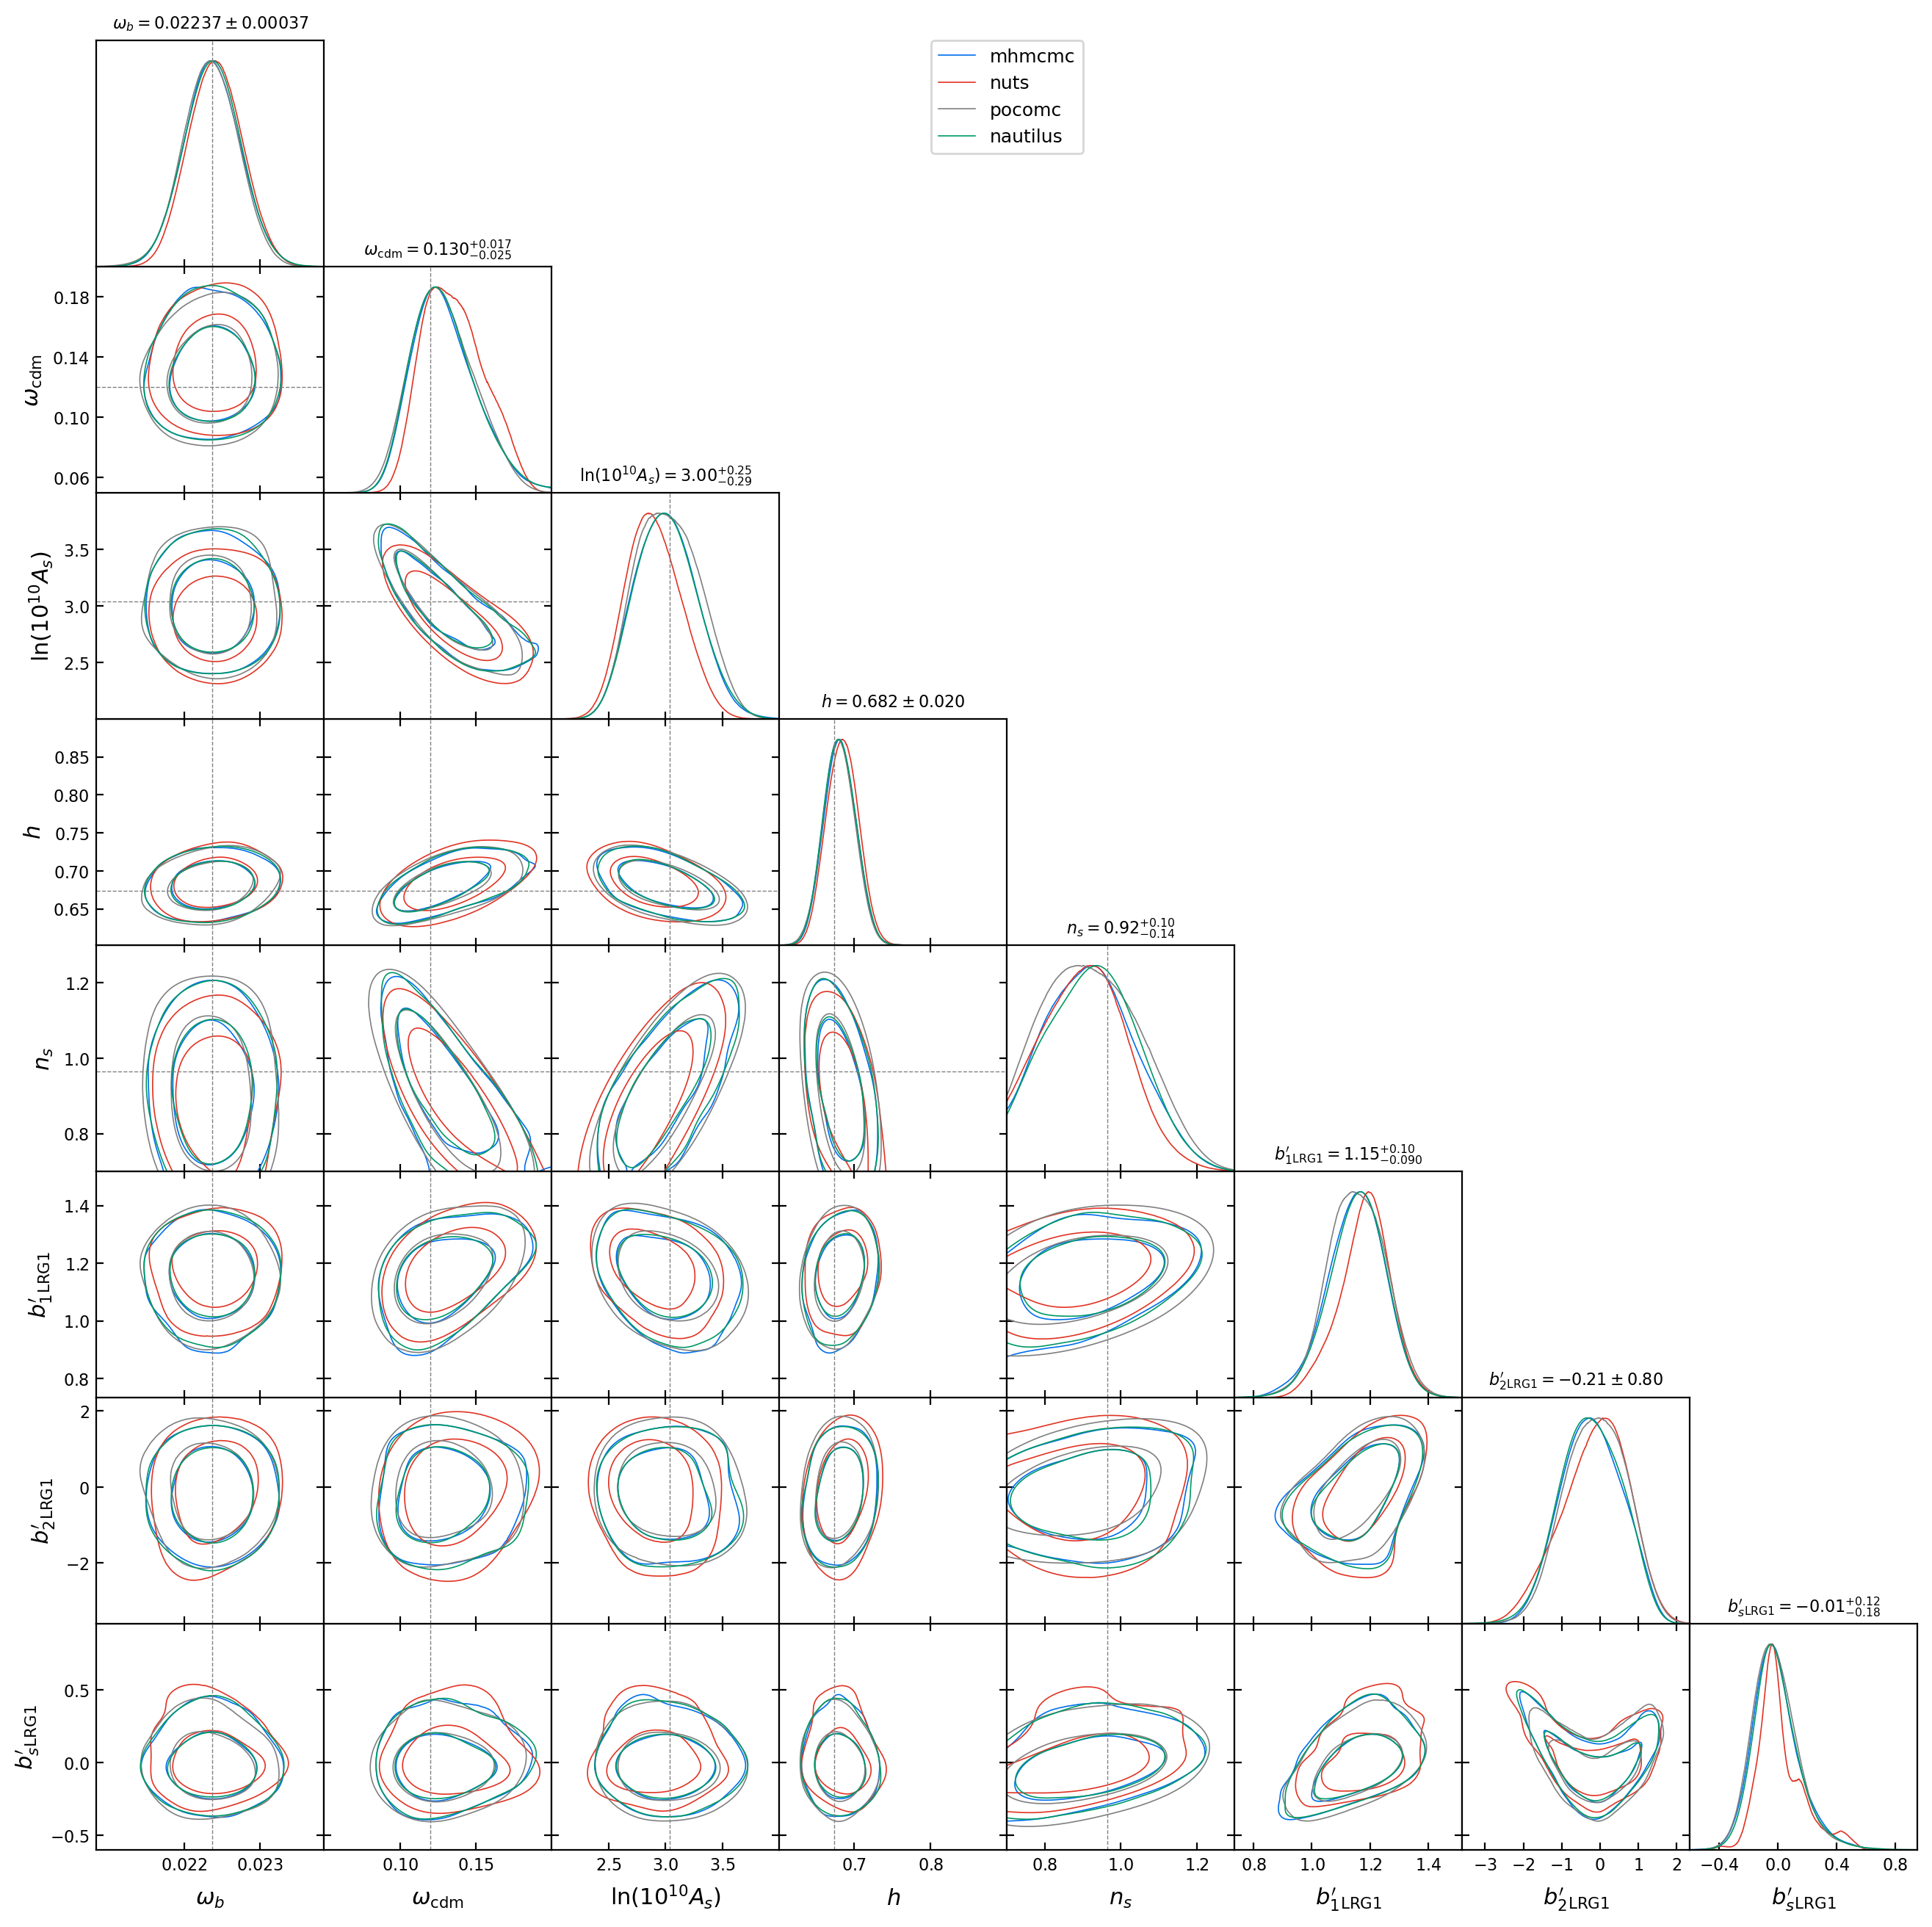

In [1]:
import sys
sys.path.insert(0, '../../../desilike')
sys.path.insert(0, '../../../desi-clustering')

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h', 'n_s', 'LRG1.b1p', 'LRG1.b2p', 'LRG1.bsp']

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

dirname = Path('/pscratch/sd/a/adematti/')
samples, legends = [], []
samples.append(read_samples([dirname / f'fits_abacus_mocks_mhmcmc/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3))
legends.append('mhmcmc')
#samples.append(read_samples([dirname / f'fits_abacus_mocks_emcee/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
#legends.append('emcee')
#samples.append(read_samples([dirname / f'fits_abacus_mocks_zeus/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples_{i + 1:d}.h5' for i in range(4)],  burnin=0.5, thin=10))
#legends.append('zeus')
samples.append(read_samples([dirname / f'fits_abacus_mocks_nuts/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples_{i + 1:d}.h5' for i in range(1)], burnin=0.2))
legends.append('nuts')
samples.append(read_samples(dirname / 'fits_abacus_mocks_pocomc/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples.h5', thin=10))
legends.append('pocomc')
samples.append(read_samples(dirname / 'fits_abacus_mocks_nautilus/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2-a029b9e2/samples.h5'))
legends.append('nautilus')

plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
plt.show()

Removed no burn in
Removed no burn in


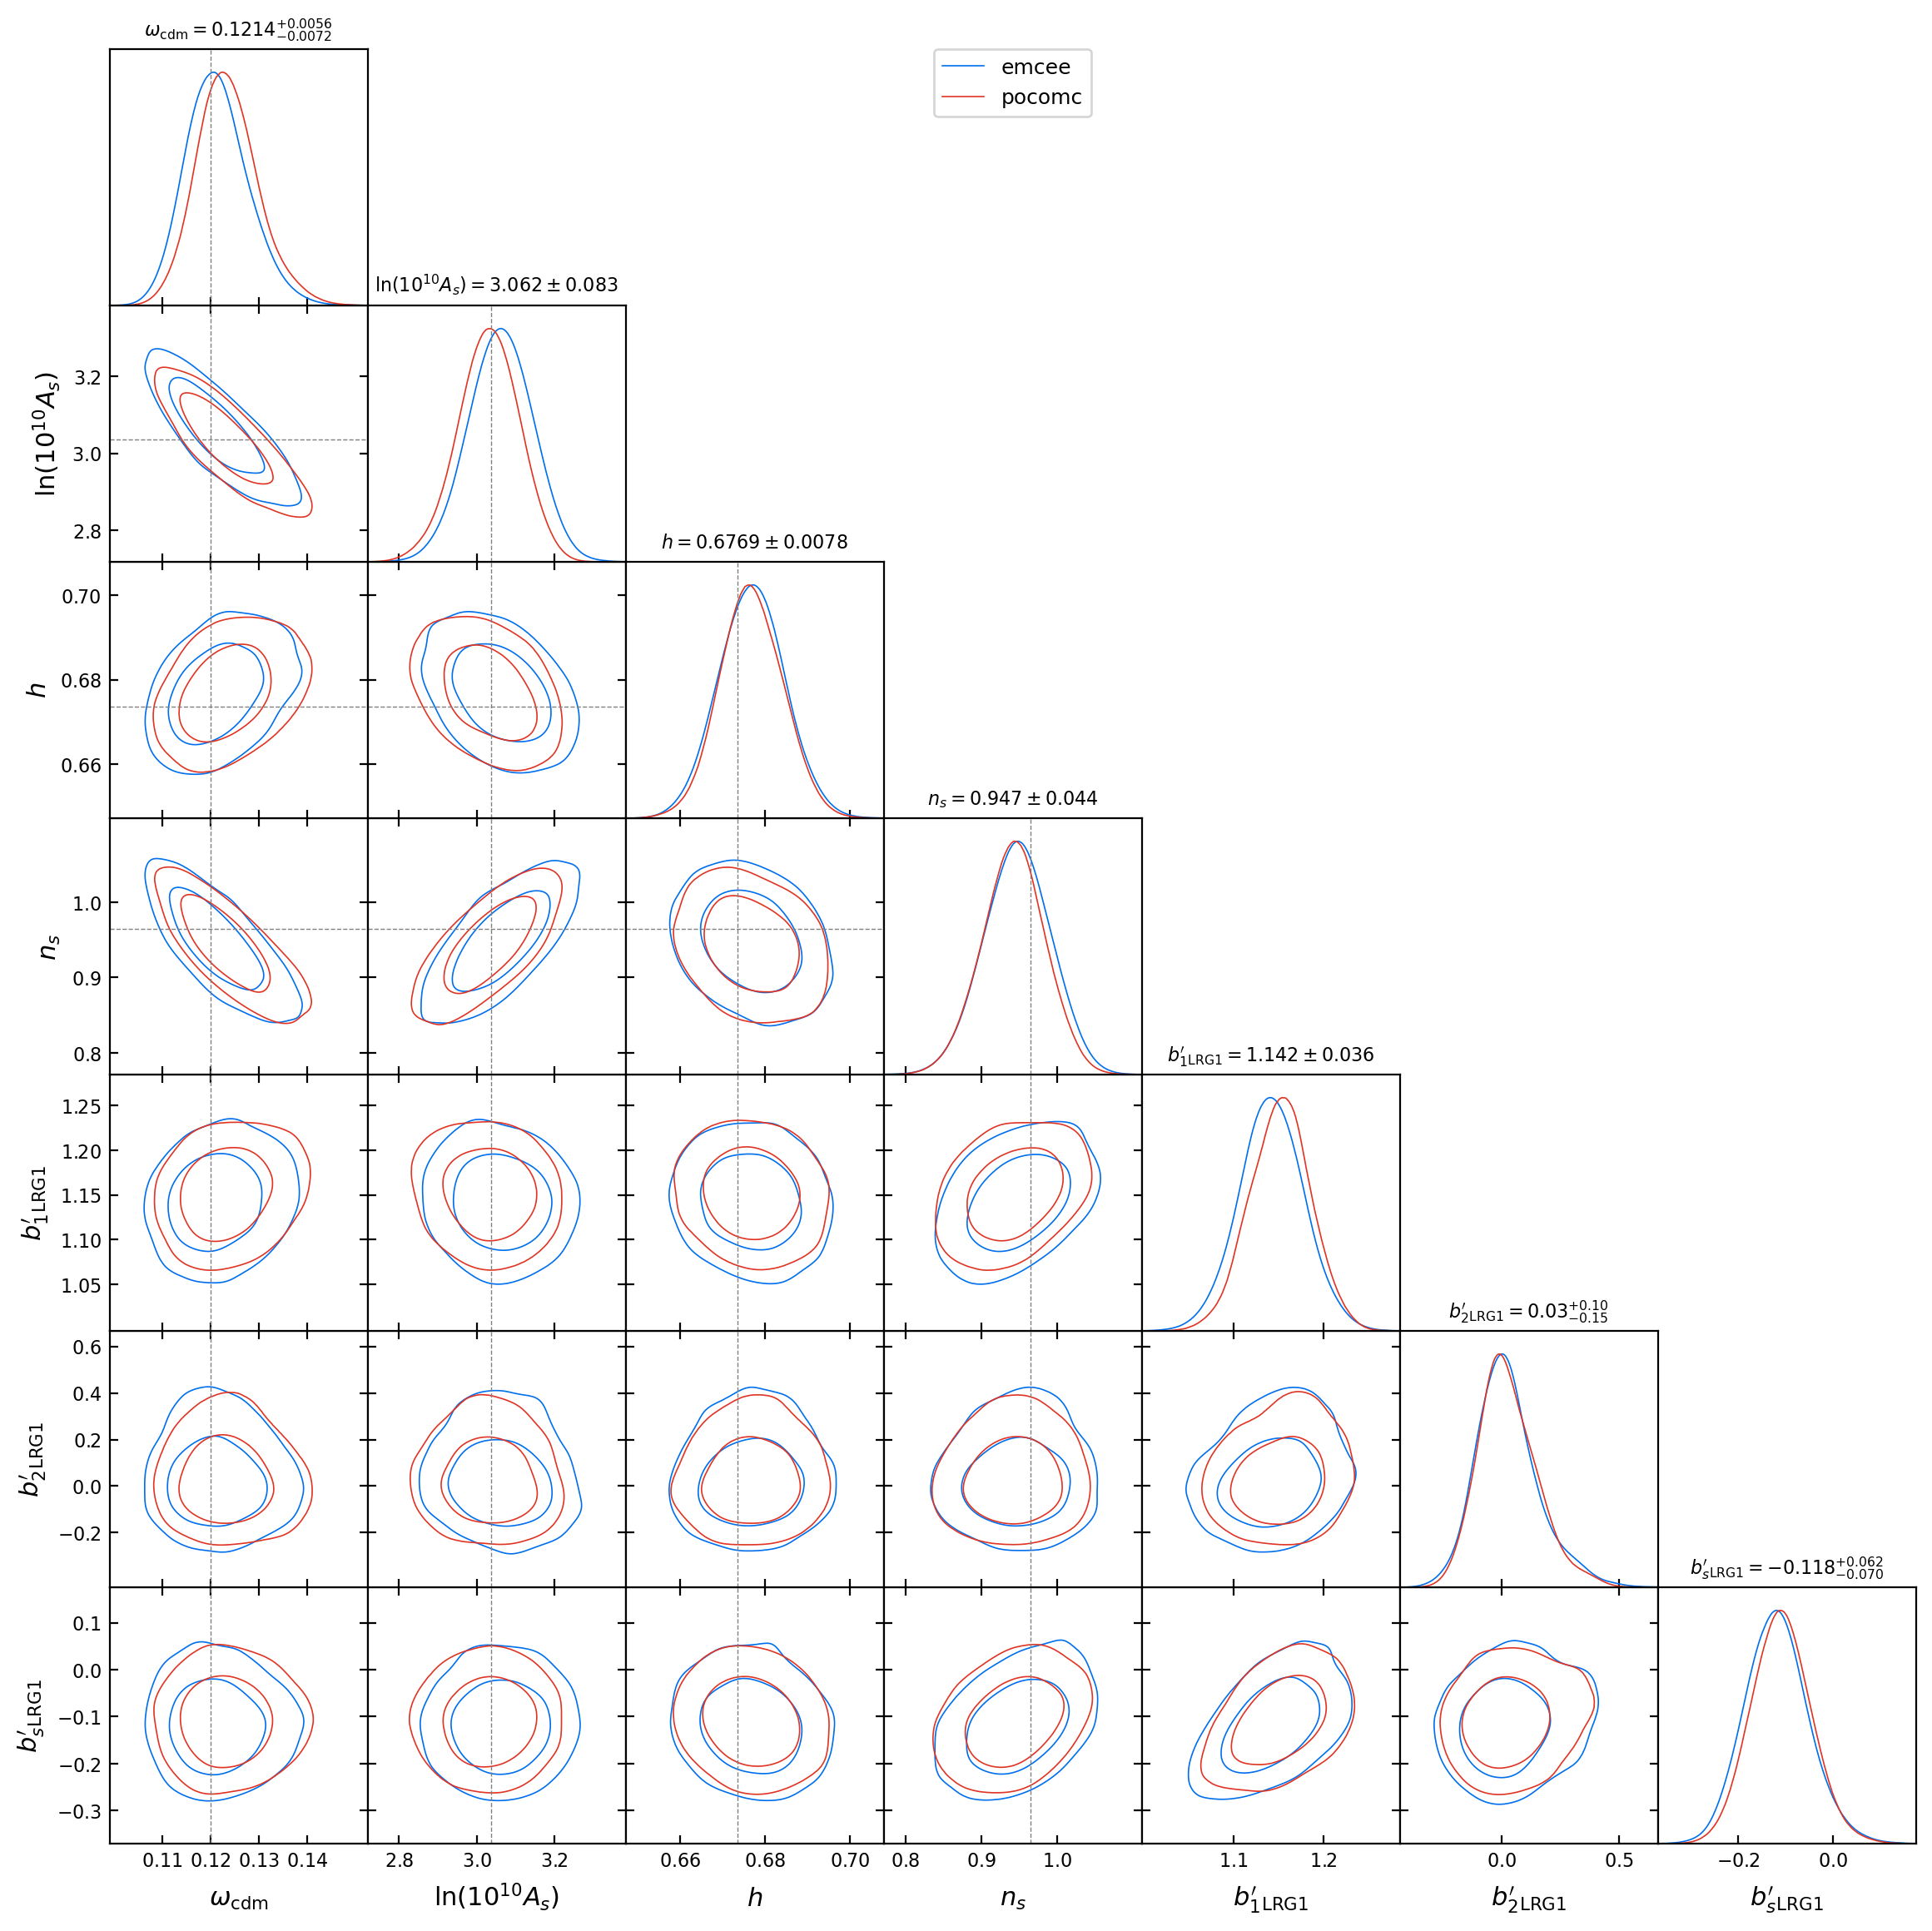

In [7]:
dirname = Path('/pscratch/sd/a/adematti/')

params_toplot = ['omega_cdm', 'logA', 'h', 'n_s', 'LRG1.b1p', 'LRG1.b2p', 'LRG1.bsp', 'QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp']

samples, legends = [], []
samples.append(read_samples([dirname / f'fits_abacus_emcee2/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2+LRG1-S3_LRG3-S2+LRG3-S3_LRG3-S2+LRG3-S3_ELG2-S2+ELG2-S3-9d58e16a/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=20))
legends.append('emcee')
samples.append(read_samples(dirname / 'fits_abacus_mocks_pocomc2/abacus-2ndgen-dr2-complete/cosmo-base_LRG1-S2+LRG1-S3_LRG3-S2+LRG3-S3_LRG3-S2+LRG3-S3_ELG2-S2+ELG2-S3-9d58e16a/samples.h5'))
legends.append('pocomc')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
plt.show()